# Session 1 - Your "first" DataScience problem

In [1]:
# some imports

from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)
 
# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
plt.rc('font', size=12) 
plt.rc('figure', figsize = (12, 5))

# Settings for the visualizations
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1, rc={"lines.linewidth": 2,'font.family': [u'times']})

import pandas as pd
pd.set_option('display.max_rows', 25)
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_colwidth', 50)

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

# create output folder
if not os.path.exists('output'):
    os.makedirs('output')
if not os.path.exists('output/session1'):
    os.makedirs('output/session1')

C:\Users\pablo\AppData\Local\Temp\ipykernel_19080\2121538162.py:3: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [2]:
## load data
train_set = pd.read_csv('train_set.csv',index_col=0) 
test_set = pd.read_csv('test_set.csv',index_col=0) 


## The problem
The machine learning is to predict the house price, but before that it is imporntat to study the dataset and its features

In [3]:
# print the dataset size
print("There is", train_set.shape[0], "samples")
print("Each sample has", train_set.shape[1], "features")

There is 5432 samples
Each sample has 21 features


In [4]:
# print the top elements from the dataset
train_set.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
index,,,,,,,,,,,,,,,,,,,,,
0,Aberfeldie,241 Buckley St,4,h,1380000.0,VB,Nelson,12/08/2017,7.5,3040.0,4.0,2.0,2.0,766.0,NaN,NaN,Moonee Valley,-37.75595,144.90551,Western Metropolitan,1543.0
1,Northcote,67 Charles St,2,h,1100000.0,SP,Jellis,20/05/2017,5.5,3070.0,2.0,1.0,1.0,189.0,NaN,NaN,Darebin,-37.77670,144.99240,Northern Metropolitan,11364.0
2,Balwyn North,42 Maud St,3,h,1480000.0,PI,Jellis,15/10/2016,9.2,3104.0,3.0,1.0,4.0,605.0,116.0,1950.0,Boroondara,-37.79510,145.06960,Southern Metropolitan,7809.0
3,Brunswick,13 Percy St,3,h,1055000.0,S,Nelson,7/05/2016,5.2,3056.0,3.0,1.0,1.0,324.0,NaN,1930.0,Moreland,-37.76530,144.95860,Northern Metropolitan,11918.0
4,Templestowe Lower,253 Thompsons Rd,4,h,1000000.0,VB,hockingstuart,13/08/2016,13.8,3107.0,4.0,3.0,2.0,728.0,164.0,1970.0,Manningham,-37.76800,145.10270,Eastern Metropolitan,5420.0


In [5]:
# As it can be seen the database contains several features, some of them numerical and some of them are categorical.
# It is important to check each of the to understand it.

In [6]:
# we can see the type of each features as follows
train_set.dtypes

Suburb            object
Address           object
Rooms              int64
Type              object
Price            float64
Method            object
SellerG           object
Date              object
Distance         float64
Postcode         float64
Bedroom2         float64
Bathroom         float64
Car              float64
Landsize         float64
BuildingArea     float64
YearBuilt        float64
CouncilArea       object
Lattitude        float64
Longtitude       float64
Regionname        object
Propertycount    float64
dtype: object

In [7]:
# print those categorical features
train_set.select_dtypes(include=['object']).head()

,Suburb,Address,Type,Method,SellerG,Date,CouncilArea,Regionname
index,,,,,,,,
0,Aberfeldie,241 Buckley St,h,VB,Nelson,12/08/2017,Moonee Valley,Western Metropolitan
1,Northcote,67 Charles St,h,SP,Jellis,20/05/2017,Darebin,Northern Metropolitan
2,Balwyn North,42 Maud St,h,PI,Jellis,15/10/2016,Boroondara,Southern Metropolitan
3,Brunswick,13 Percy St,h,S,Nelson,7/05/2016,Moreland,Northern Metropolitan
4,Templestowe Lower,253 Thompsons Rd,h,VB,hockingstuart,13/08/2016,Manningham,Eastern Metropolitan


In [8]:
# We can check how many different type there is in the dataset using the following line
train_set["Type"].value_counts()

Type
h    3765
u    1191
t     476
Name: count, dtype: int64

C:\Users\pablo\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\pablo\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\pablo\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


<Axes: xlabel='count', ylabel='Type'>

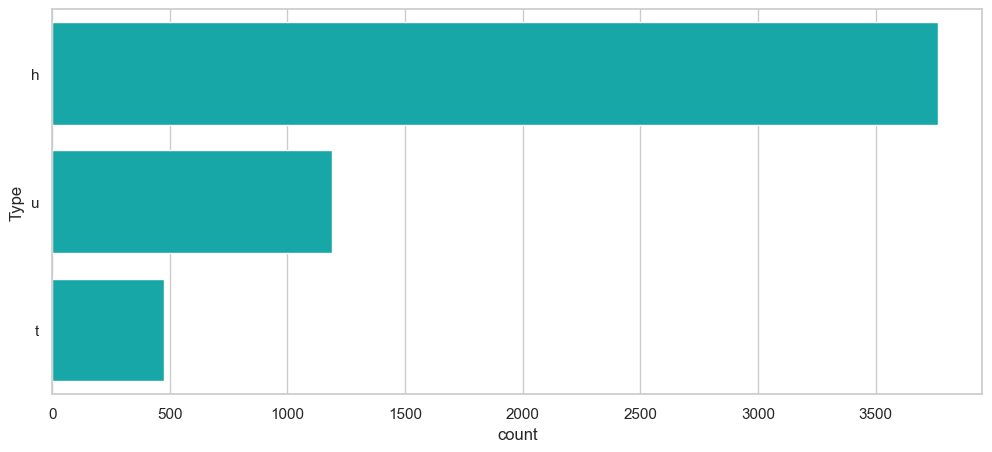

In [9]:
sns.countplot(y="Type", data=train_set, color="c")

It would be interesting to visualize all features (numerical and catergorical) in order to undertand them.

Check out this blog for plotting distribution: https://seaborn.pydata.org/tutorial/distributions.html
+ Seaborn version of this blog can be different from the one installed in your machine (version 0.11 has just been released)

Check out this blog for plotting categorical data: https://seaborn.pydata.org/tutorial/categorical.html

C:\Users\pablo\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\pablo\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


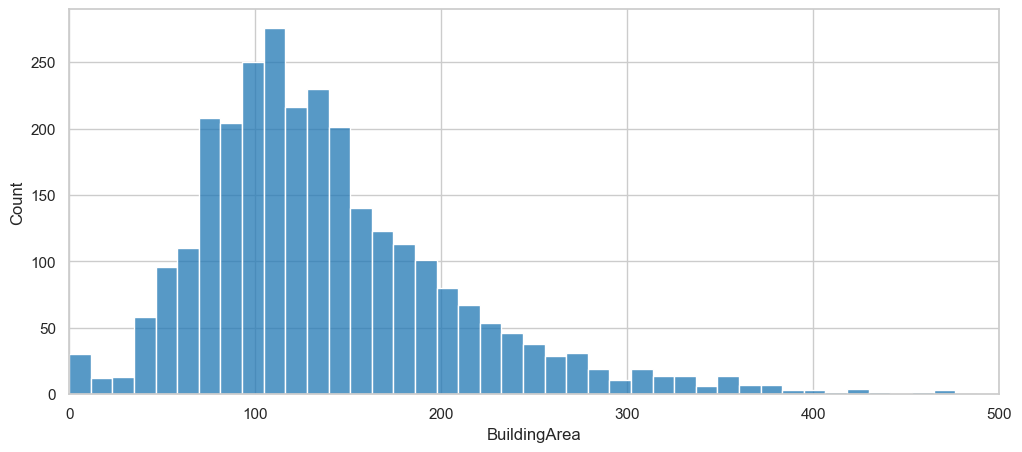

In [10]:
plt.xlim(0, 500)
sns.histplot(train_set["BuildingArea"])
plt.show()

## BASELINE MODEL
### https://www.kaggle.com/c/mlub2021-session1/notebooks

This is a simple model that uses the K-nearest Neighbors Regressor

This model only uses 4 feaures: 'Rooms','Landsize', 'BuildingArea', 'YearBuilt'

----- EVALUATION ON TRAIN SET ------
RMSE 398979.18860008445
R^2:  0.6197370233507158


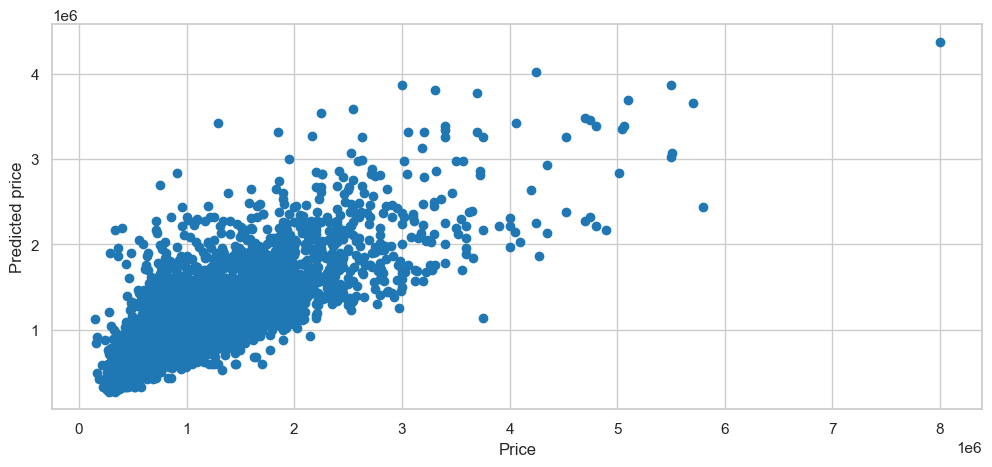

In [11]:
## the features

features = ['Rooms','Landsize', 'BuildingArea', 'YearBuilt']
## DEFINE YOUR FEATURES
X = train_set[features].fillna(0)
y = train_set[['Price']]

## the model
# KNeighborsRegressor
from sklearn import neighbors
n_neighbors = 3 # you can modify this parameter (ONLY THIS ONE!!!)
model = neighbors.KNeighborsRegressor(n_neighbors)

## fit the model
model.fit(X, y)

## predict training set
y_pred = model.predict(X)

## Evaluate the model and plot it
from sklearn.metrics import mean_squared_error, r2_score
print("----- EVALUATION ON TRAIN SET ------")
print("RMSE",np.sqrt(mean_squared_error(y, y_pred)))
print("R^2: ",r2_score(y, y_pred))


plt.scatter(y, y_pred)
plt.xlabel('Price')
plt.ylabel('Predicted price')
plt.show()

## predict the test set and generate the submission file
X_test = test_set[features].fillna(0)
y_pred = model.predict(X_test)

df_output = pd.DataFrame(y_pred)
df_output = df_output.reset_index()
df_output.columns = ['index','Price']

df_output.to_csv('output/session1/baseline.csv',index=False)

## EXERCICE - TRAIN A MODEL and upload your best solution to the Kaggle Challenge

Tasks: 
+ Choose the best features for the problem. Some features are numerical but others categorical, think how to codify all of them.
+ Choose the model. You have two choice: LinearRegression and KNeighborsRegressor
    + You can change the parameter n_neighbors from the KNeighborsRegressor
    
LINEAR REGRESSOR:
>from sklearn.linear_model import LinearRegression

>model = LinearRegression()

KNeighborsRegressor
> from sklearn import neighbors

> n_neighbors = 3 # you can modify this parameter (ONLY THIS ONE!!!)

> model = neighbors.KNeighborsRegressor(n_neighbors=n_neighbors)


## Pablo Prol Prieto and Pablo Sala Fernández ( Team Pablo(s) in kaggle)

In [12]:
# reload data
train_set = pd.read_csv('train_set.csv',index_col=0)

In [13]:
## the features
# We will clean the data
# Since later we will use a linear regression model, we will drop the rows with 'Price' values greater or equal to 3 million, since they are outliers
train_set = train_set[train_set['Price'] < 3250000]
# Let's now handle the columns with missing values:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5363 entries, 0 to 5431
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         5363 non-null   object 
 1   Address        5363 non-null   object 
 2   Rooms          5363 non-null   int64  
 3   Type           5363 non-null   object 
 4   Price          5363 non-null   float64
 5   Method         5363 non-null   object 
 6   SellerG        5363 non-null   object 
 7   Date           5363 non-null   object 
 8   Distance       5363 non-null   float64
 9   Postcode       5363 non-null   float64
 10  Bedroom2       5363 non-null   float64
 11  Bathroom       5363 non-null   float64
 12  Car            5338 non-null   float64
 13  Landsize       5363 non-null   float64
 14  BuildingArea   2849 non-null   float64
 15  YearBuilt      3264 non-null   float64
 16  CouncilArea    4818 non-null   object 
 17  Lattitude      5363 non-null   float64
 18  Longtitude   

In [14]:
# We can see from the output of the previous cell that there are some missing values in the dataset
# Specifically, there are missing values in the following columns:
# - Car
# - BuildingArea
# - YearBuilt
# - CouncilArea
# We can use the following line to check the ratio of missing values in each of these columns:
print("NaN ratios: ", "\n", 
"Car:", train_set['Car'].isnull().sum()/len(train_set['Car']), "\n", 
"BuildingArea:", train_set['BuildingArea'].isnull().sum()/len(train_set['BuildingArea']), "\n",
"YearBuilt:", train_set['YearBuilt'].isnull().sum()/len(train_set['YearBuilt']), "\n",
"CouncilArea:", train_set['CouncilArea'].isnull().sum()/len(train_set['CouncilArea']))

NaN ratios:  
 Car: 0.004661570016781652 
 BuildingArea: 0.4687674808875629 
 YearBuilt: 0.3913854186089875 
 CouncilArea: 0.10162222636584002


In [15]:
# We fill the missing values in the 'Car' column with the mean of the column grouped by the 'Suburb' column, since we think the number of cars in a house is mostly affected by the suburb
train_set['Car'] = train_set.groupby('Suburb')['Car'].transform(lambda x: x.fillna(x.mean()))

# We can drop the 'CouncilArea' column since it gives information about the house location, which is already given by the 'Suburb' which will be more precise and has no NaN values
train_set = train_set.drop(columns=['CouncilArea'])

# For the 'BuildingArea' and 'YearBuilt' columns, we can replace the missing values with the mean of the column within the same suburb, since we think the size and age of the house are also mostly influenced by the suburb
train_set['BuildingArea'] = train_set.groupby('Suburb')['BuildingArea'].transform(lambda x: x.fillna(x.mean()))
train_set['YearBuilt'] = train_set.groupby('Suburb')['YearBuilt'].transform(lambda x: x.fillna(x.mean()))

# This won't eliminate all the missing values (because there are suburbs in which these features are all NaN for all houses), so we will drop the remaining rows with missing values
train_set = train_set.dropna(subset=['BuildingArea', 'YearBuilt'])

# We will do everything we did to the training set to the test set except for dropping rows. We put the mean instead
test_set['Car'] = test_set.groupby('Suburb')['Car'].transform(lambda x: x.fillna(x.mean()))
test_set['Car'] = test_set['Car'].transform(lambda x: x.fillna(x.mean()))
test_set = test_set.drop(columns=['CouncilArea'])
test_set['BuildingArea'] = test_set.groupby('Suburb')['BuildingArea'].transform(lambda x: x.fillna(x.mean()))
test_set['YearBuilt'] = test_set.groupby('Suburb')['YearBuilt'].transform(lambda x: x.fillna(x.mean()))
test_set['BuildingArea'] = test_set['BuildingArea'].transform(lambda x: x.fillna(x.mean()))
test_set['YearBuilt'] = test_set['YearBuilt'].transform(lambda x: x.fillna(x.mean()))

# For the rows in test_set with -inf values in 'Landsize', we replace them with the mean of the 'Landsize' column
test_set.loc[[2295, 5177, 6824], 'Landsize'] = test_set['Landsize'].mean()

In [16]:
# We will encode the categorical columns
# To properly choose a method to encode the categorical columns, we will first check the number of unique values in each one of them
print("Number of unique values in each categorical column: ", "\n",
"Suburb:", len(train_set['Suburb'].unique()), "\n",
"Address:", len(train_set['Address'].unique()), "\n",
"Type:", len(train_set['Type'].unique()), "\n",
"Method:", len(train_set['Method'].unique()), "\n",
"Regionname:", len(train_set['Regionname'].unique()), "\n",
"Propertycount:", len(train_set['Propertycount'].unique()), "\n", 
"SellerG:", len(train_set['SellerG'].unique()))

Number of unique values in each categorical column:  
 Suburb: 265 
 Address: 5281 
 Type: 3 
 Method: 5 
 Regionname: 8 
 Propertycount: 263 
 SellerG: 199


In [17]:
# From the output of the previous cell, we can see that the 'Address' column has a unique value almost for each row, so we will drop this column since it will not give us any useful information
train_set = train_set.drop(columns=['Address'])
test_set = test_set.drop(columns=['Address'])

# Since there are many unique values for "SellerG", we will hash encode this column
train_set['SellerG'] = train_set['SellerG'].apply(hash)
test_set['SellerG'] = test_set['SellerG'].apply(hash)

# Since there are few unique values in the 'Type', 'Regionname' and 'Method' columns, we can one-hot encode them
train_set = pd.get_dummies(train_set, columns=['Type', 'Regionname', 'Method'])
test_set = pd.get_dummies(test_set, columns=['Type', 'Regionname', 'Method'])

In [18]:
# We will check if 'Propertycount' is the same for each suburb
train_set.groupby('Propertycount')['Suburb'].nunique()

Propertycount
389.0      1
438.0      1
534.0      1
588.0      1
768.0      1
          ..
17055.0    1
17093.0    1
17384.0    1
17496.0    1
21650.0    1
Name: Suburb, Length: 263, dtype: int64

In [19]:
# We can see that each suburb has a 'Propertycount' value, and except for 3 suburbs all the values are different (7082.0, 8870.0 and 2674.0 are 'Propertycount' values each corresponding to 2 different suburbs)
# Therefore we will drop the 'Propertycount' column since it will not give us any useful information and it is redundant with the 'Suburb' column
train_set = train_set.drop(columns=['Propertycount'])
test_set = test_set.drop(columns=['Propertycount'])

# We will hash encode the 'Suburb' column
train_set['Suburb'] = train_set['Suburb'].apply(hash)
test_set['Suburb'] = test_set['Suburb'].apply(hash)

In [20]:
# For the 'Date' column, we will extract the year and month from the date and use them as two new columns
train_set['Date'] = pd.to_datetime(train_set['Date'], dayfirst=True)
train_set['Year'] = train_set['Date'].dt.year
train_set['Month'] = train_set['Date'].dt.month
train_set = train_set.drop(columns=['Date'])

# We will do everything we did to the training set to the test set as well
test_set['Date'] = pd.to_datetime(test_set['Date'], dayfirst=True)
test_set['Year'] = test_set['Date'].dt.year
test_set['Month'] = test_set['Date'].dt.month
test_set = test_set.drop(columns=['Date'])

In [21]:
# For the columns 'Landsize', 'BuildingArea', 'Bathroom', 'Bedroom2', and 'Car' we will change the zero values to the mean of the column grouped by the 'Suburb' column
train_set['Landsize'] = train_set.groupby('Suburb')['Landsize'].transform(lambda x: x.replace(0, x.mean()))
# Since there are suburbs where all houses have a 'Landsize' of 0, we will replace the remaining 0 values with the mean of the column
train_set['Landsize'] = train_set['Landsize'].transform(lambda x: x.replace(0, x.mean()))
train_set['BuildingArea'] = train_set.groupby('Suburb')['BuildingArea'].transform(lambda x: x.replace(0, x.mean()))
train_set['Bathroom'] = train_set.groupby('Suburb')['Bathroom'].transform(lambda x: x.replace(0, x.mean()))
train_set['Bedroom2'] = train_set.groupby('Suburb')['Bedroom2'].transform(lambda x: x.replace(0, x.mean()))
train_set['Car'] = train_set.groupby('Suburb')['Car'].transform(lambda x: x.replace(0, x.mean()))

# We will do everything we did to the training set to the test set as well
test_set['Landsize'] = test_set.groupby('Suburb')['Landsize'].transform(lambda x: x.replace(0, x.mean()))
test_set['Landsize'] = test_set['Landsize'].transform(lambda x: x.replace(0, x.mean()))
test_set['BuildingArea'] = test_set.groupby('Suburb')['BuildingArea'].transform(lambda x: x.replace(0, x.mean()))
test_set['Bathroom'] = test_set.groupby('Suburb')['Bathroom'].transform(lambda x: x.replace(0, x.mean()))
test_set['Bedroom2'] = test_set.groupby('Suburb')['Bedroom2'].transform(lambda x: x.replace(0, x.mean()))
test_set['Car'] = test_set.groupby('Suburb')['Car'].transform(lambda x: x.replace(0, x.mean()))

array([[<Axes: title={'center': 'Suburb'}>,
        <Axes: title={'center': 'Rooms'}>,
        <Axes: title={'center': 'Price'}>,
        <Axes: title={'center': 'SellerG'}>],
       [<Axes: title={'center': 'Distance'}>,
        <Axes: title={'center': 'Postcode'}>,
        <Axes: title={'center': 'Bedroom2'}>,
        <Axes: title={'center': 'Bathroom'}>],
       [<Axes: title={'center': 'Car'}>,
        <Axes: title={'center': 'Landsize'}>,
        <Axes: title={'center': 'BuildingArea'}>,
        <Axes: title={'center': 'YearBuilt'}>],
       [<Axes: title={'center': 'Lattitude'}>,
        <Axes: title={'center': 'Longtitude'}>,
        <Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Month'}>]], dtype=object)

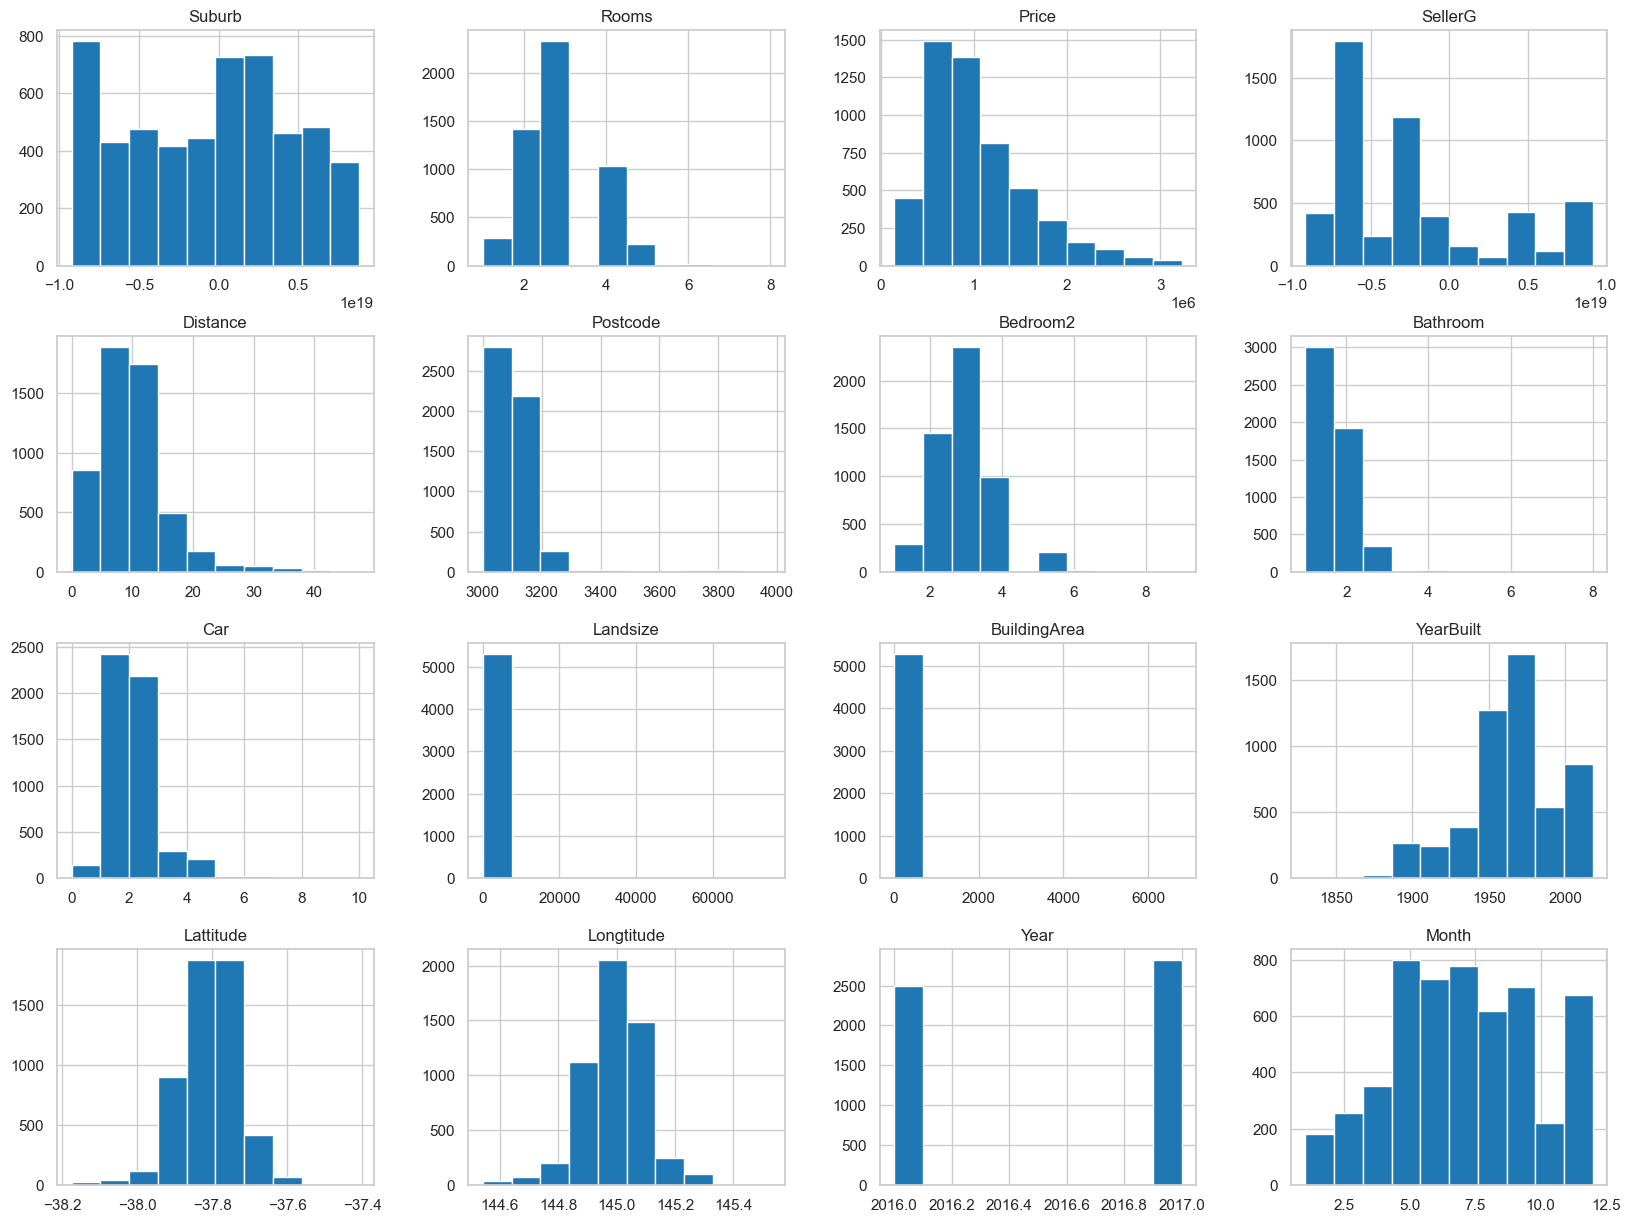

In [22]:
# We will do a numerical exploration of the dataset by plotting the distribution of each numerical column
train_set.hist(figsize=(20, 15))

array([[<Axes: title={'center': 'Suburb'}>,
        <Axes: title={'center': 'Rooms'}>,
        <Axes: title={'center': 'Price'}>,
        <Axes: title={'center': 'SellerG'}>],
       [<Axes: title={'center': 'Distance'}>,
        <Axes: title={'center': 'Postcode'}>,
        <Axes: title={'center': 'Bedroom2'}>,
        <Axes: title={'center': 'Bathroom'}>],
       [<Axes: title={'center': 'Car'}>,
        <Axes: title={'center': 'Landsize'}>,
        <Axes: title={'center': 'BuildingArea'}>,
        <Axes: title={'center': 'YearBuilt'}>],
       [<Axes: title={'center': 'Lattitude'}>,
        <Axes: title={'center': 'Longtitude'}>,
        <Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Month'}>],
       [<Axes: title={'center': 'TotalRooms'}>,
        <Axes: title={'center': 'DistanceCarsRatio'}>, <Axes: >,
        <Axes: >]], dtype=object)

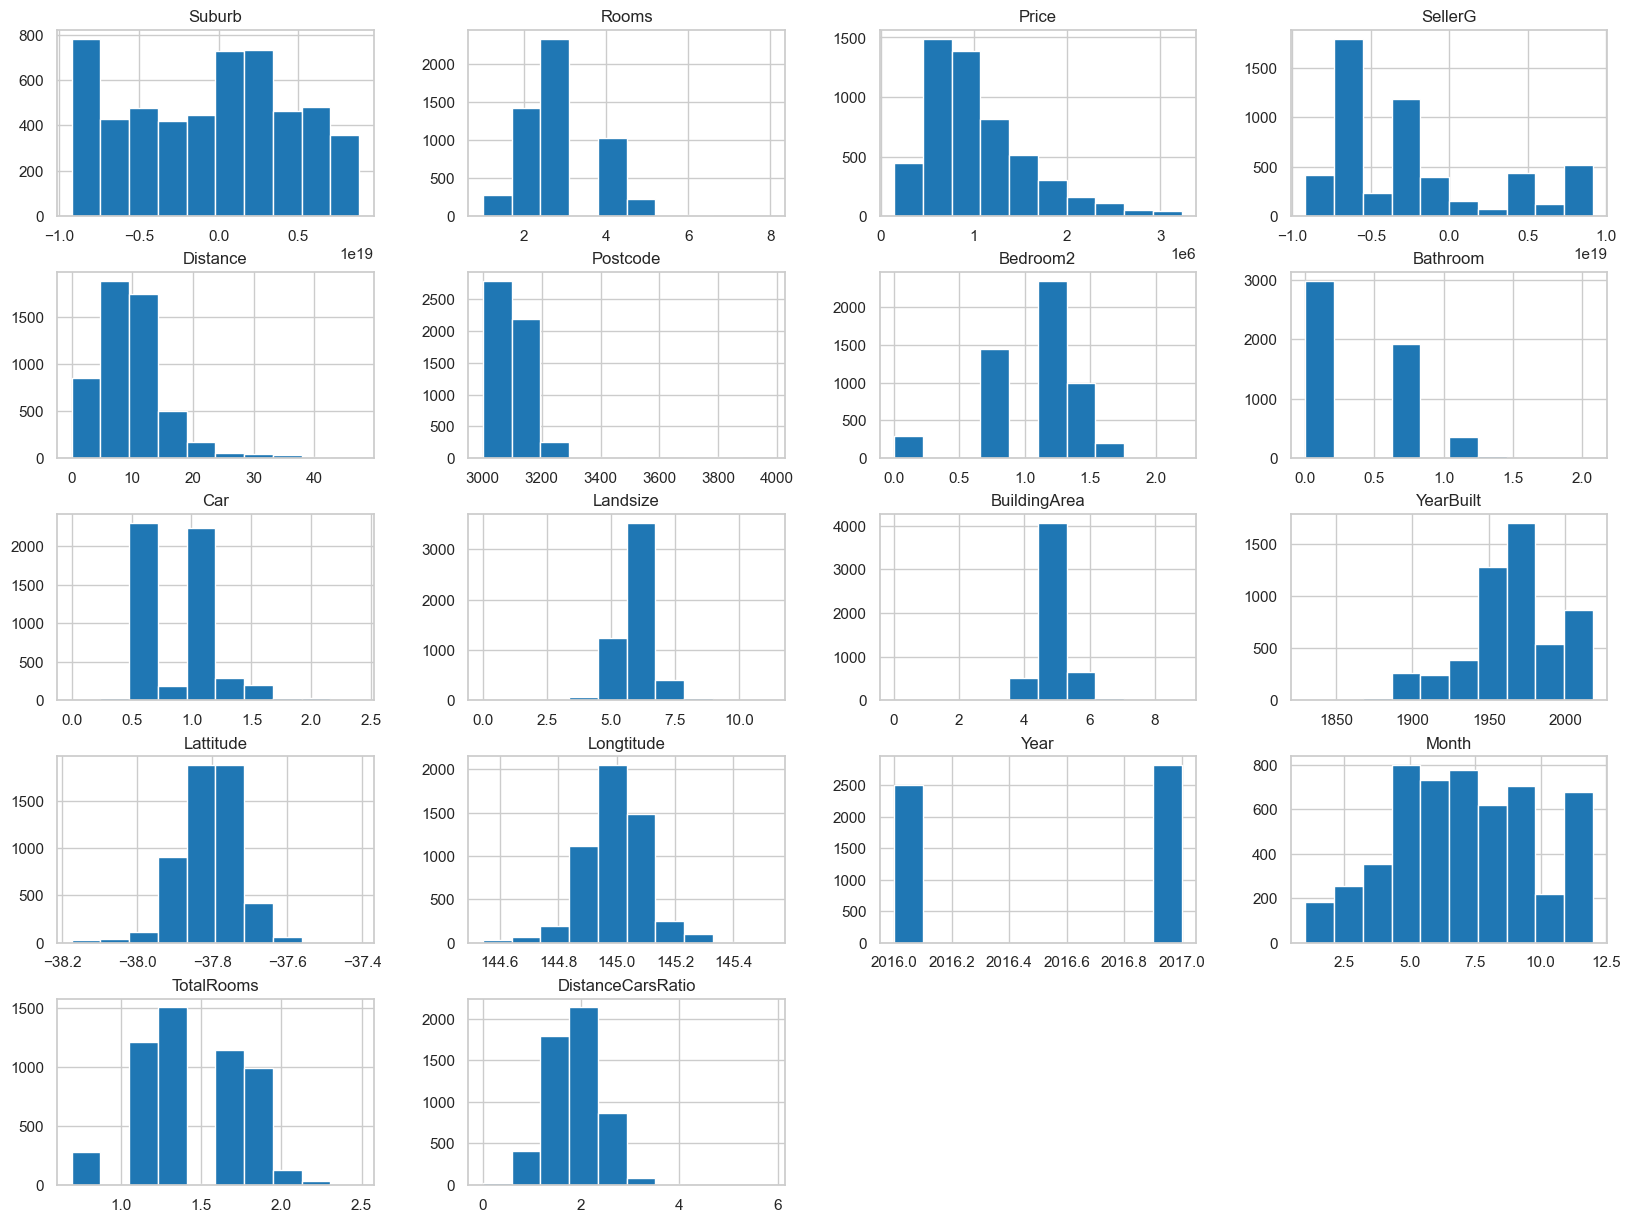

In [23]:
# We will create a feature called 'TotalRooms' which will be the sum of the 'Rooms' and 'Barhroom' columns
train_set['TotalRooms'] = train_set['Rooms'] + train_set['Bathroom']
test_set['TotalRooms'] = test_set['Rooms'] + test_set['Bathroom']

# We will create a feature called 'DistanceCarsRatio' which will be the ratio of the 'Distance' column to the 'Car' column, this could be interesting since the more distance there is to the city center, the more cars there should be to facilitate transportation.
train_set['DistanceCarsRatio'] = train_set['Distance'] / (train_set['Car'] + 0.1) # We add 0.1 to avoid division by 0
test_set['DistanceCarsRatio'] = test_set['Distance'] / (test_set['Car'] + 0.1) # We add 0.1 to avoid division by 0

# We can see that the 'BuildingArea', 'Landsize', 'Car', 'Bathroom', 'Bedroom2', 'TotalRooms' and 'DistanceCarsRatio' columns are skewed to the right, so we will apply a log transformation to them
train_set['BuildingArea'] = np.log(train_set['BuildingArea'])
train_set['Landsize'] = np.log(train_set['Landsize'])
train_set['Car'] = np.log(train_set['Car'] + 1) # We add 1 to avoid log(0)
train_set['Bathroom'] = np.log(train_set['Bathroom'])
train_set['Bedroom2'] = np.log(train_set['Bedroom2'])
train_set['TotalRooms'] = np.log(train_set['TotalRooms'])
train_set['DistanceCarsRatio'] = np.log(train_set['DistanceCarsRatio'] + 1) # We add 1 to avoid log(0)

# We will do everything we did to the training set to the test set as well
test_set['BuildingArea'] = np.log(test_set['BuildingArea'])
test_set['Landsize'] = np.log(test_set['Landsize'])
test_set['Car'] = np.log(test_set['Car'] + 1)
test_set['Bathroom'] = np.log(test_set['Bathroom'])
test_set['Bedroom2'] = np.log(test_set['Bedroom2'])
test_set['TotalRooms'] = np.log(test_set['TotalRooms'])
test_set['DistanceCarsRatio'] = np.log(test_set['DistanceCarsRatio'] + 1)

# Finally we plot the distribution of the numerical columns again to see the effect of the log transformation
train_set.hist(figsize=(20, 15))

<Axes: >

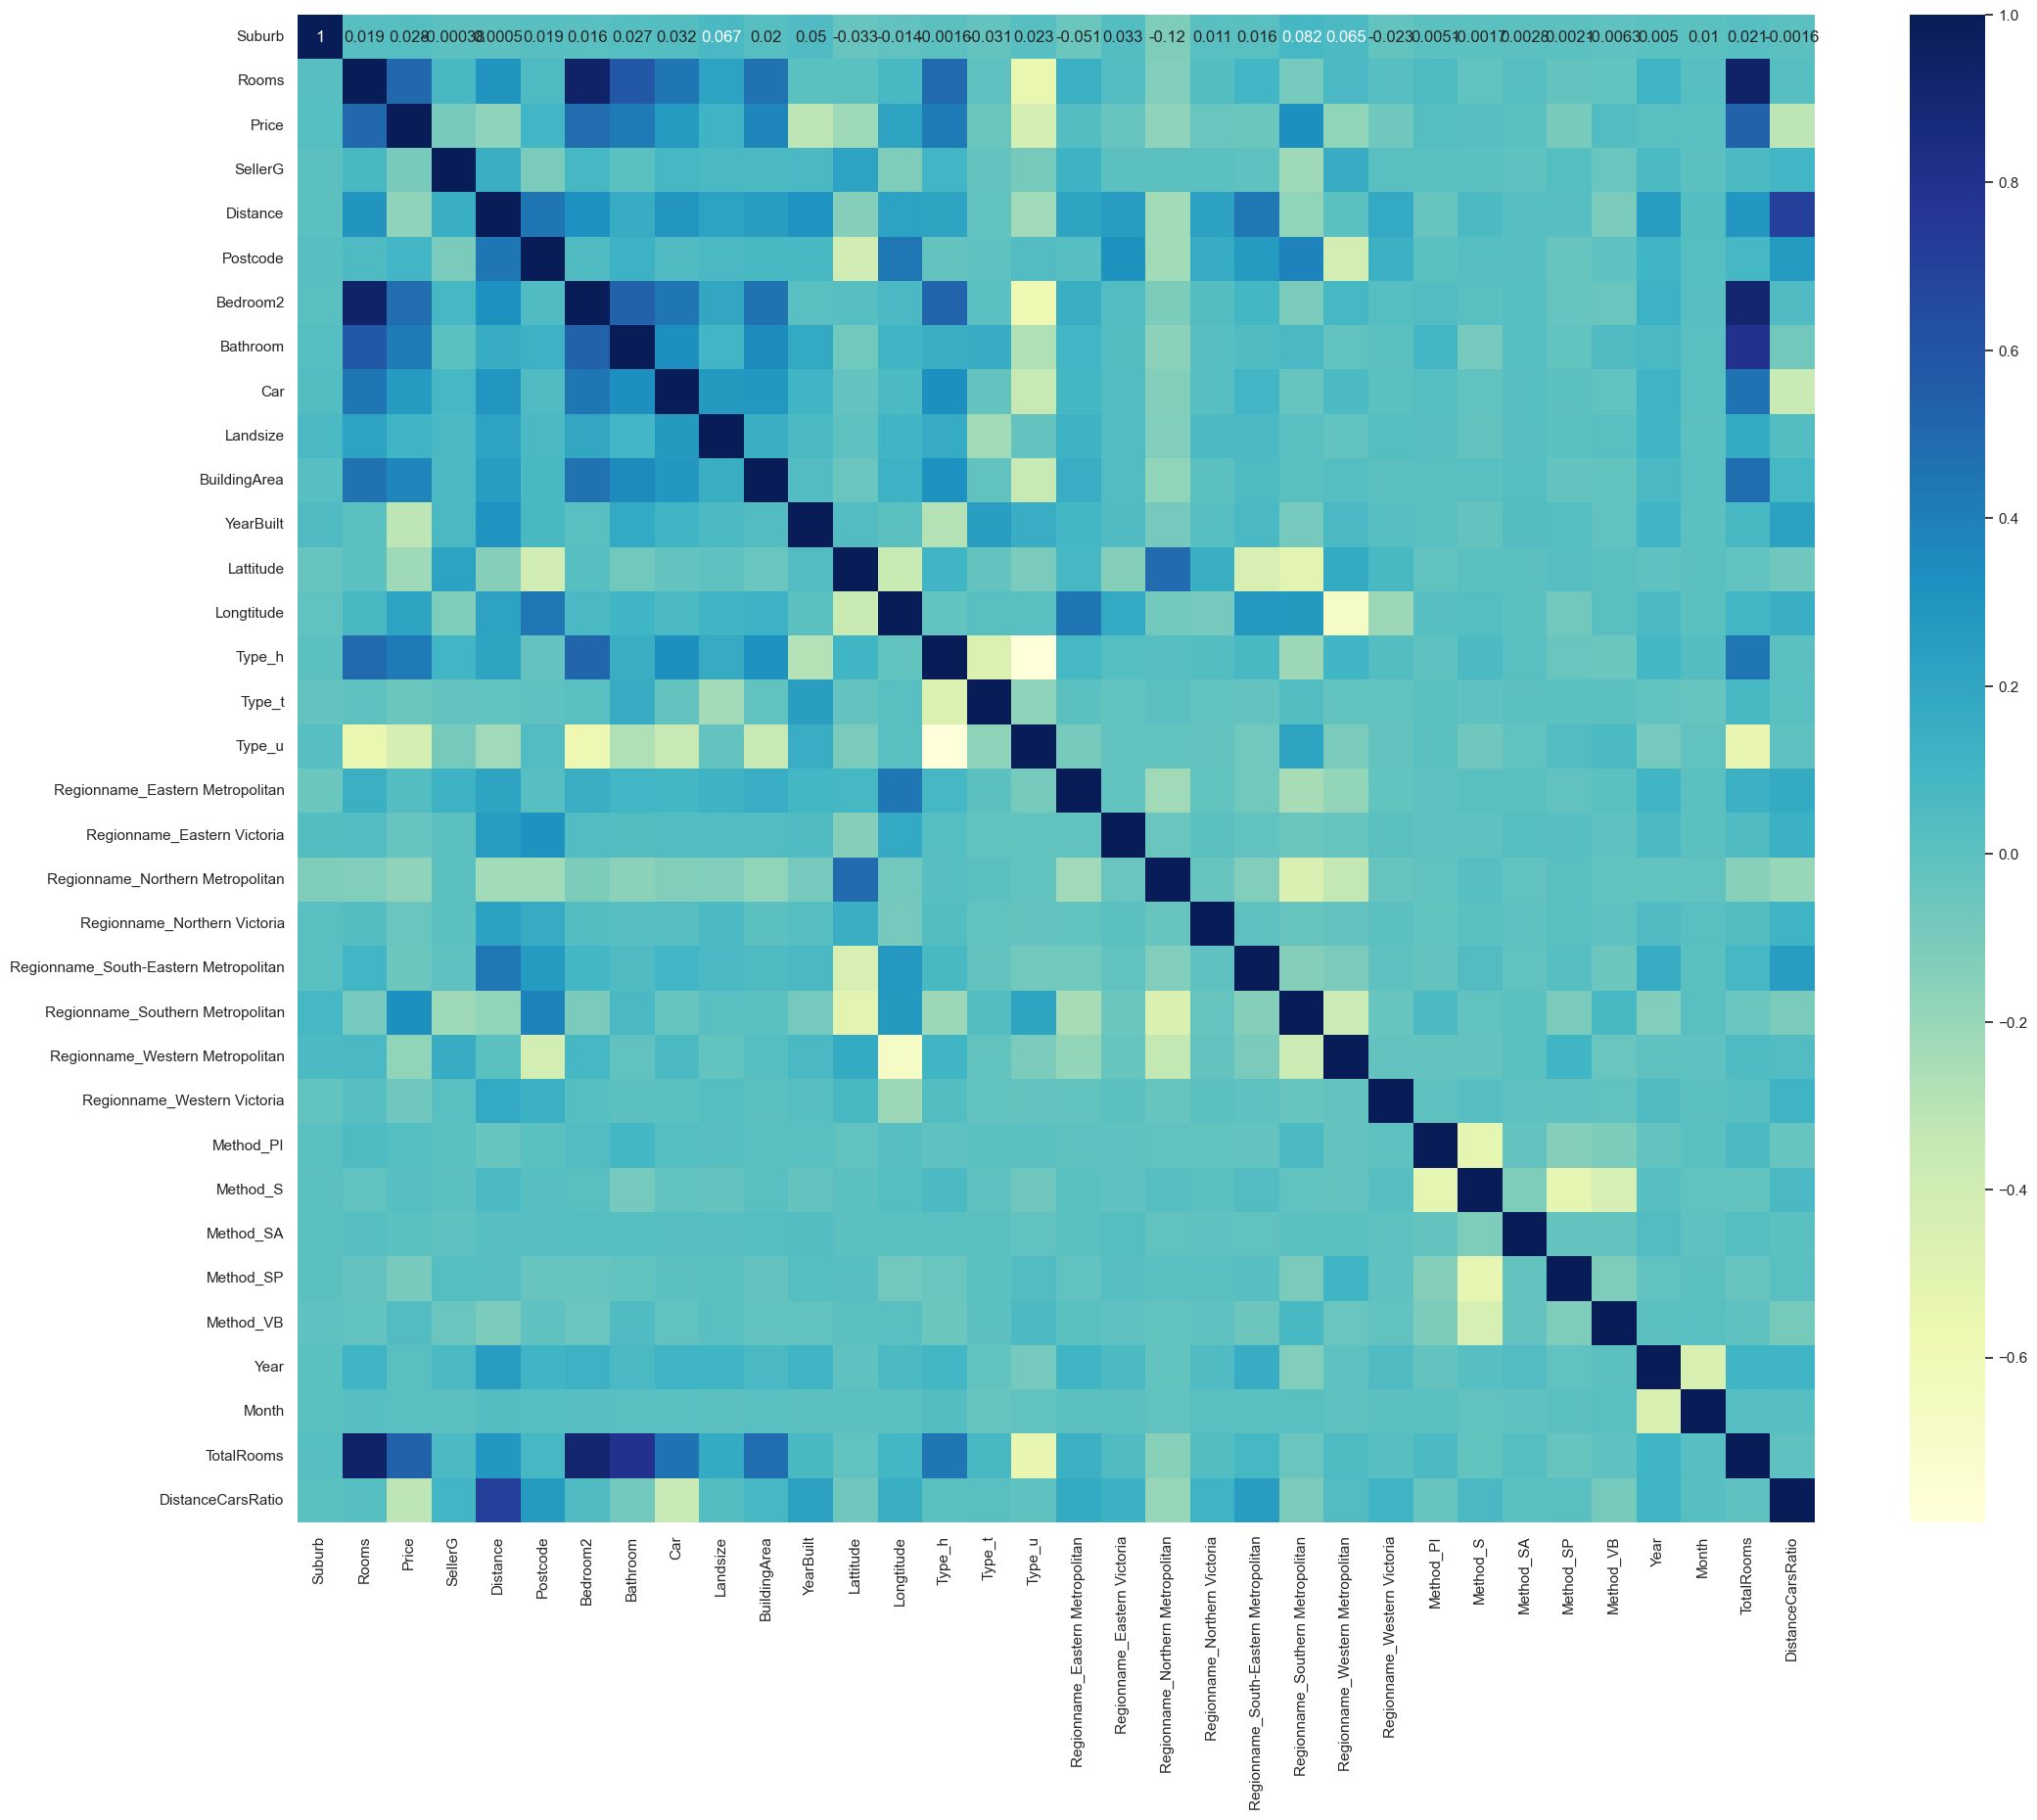

In [24]:
# We will plot a heatmap of the correlation matrix of the numerical columns with the 'Price' column
plt.figure(figsize=(25, 20))
sns.heatmap(train_set.corr(), annot=True, cmap='YlGnBu')

In [25]:
train_set

,Suburb,Rooms,Price,SellerG,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Type_h,Type_t,Type_u,Regionname_Eastern Metropolitan,Regionname_Eastern Victoria,Regionname_Northern Metropolitan,Regionname_Northern Victoria,Regionname_South-Eastern Metropolitan,Regionname_Southern Metropolitan,Regionname_Western Metropolitan,Regionname_Western Victoria,Method_PI,Method_S,Method_SA,Method_SP,Method_VB,Year,Month,TotalRooms,DistanceCarsRatio
index,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,6305608131927935896,4,1380000.0,-7228016824915177800,7.5,3040.0,1.386294,0.693147,1.098612,6.641182,5.078577,1982.307692,-37.75595,144.90551,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,2017,8,1.791759,1.519826
1,-13394348675730562,2,1100000.0,-3032932140935729316,5.5,3070.0,0.693147,0.000000,0.693147,5.241747,4.842754,1941.222222,-37.77670,144.99240,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,2017,5,1.098612,1.791759
2,-2881693640817521244,3,1480000.0,-3032932140935729316,9.2,3104.0,1.098612,0.000000,1.609438,6.405228,4.753590,1950.000000,-37.79510,145.06960,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,2016,10,1.386294,1.176777
3,-8770498466473223228,3,1055000.0,-7228016824915177800,5.2,3056.0,1.098612,0.000000,0.693147,5.780744,4.747694,1930.000000,-37.76530,144.95860,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,2016,5,1.386294,1.745239
4,3756413441526734768,4,1000000.0,-6933563622363114704,13.8,3107.0,1.386294,1.098612,1.098612,6.590301,5.099866,1970.000000,-37.76800,145.10270,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,2016,8,1.945910,2.024382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5427,6889355974687233096,3,851500.0,-7228016824915177800,11.2,3073.0,1.098612,0.000000,0.693147,6.168747,4.872973,1930.000000,-37.72170,144.99540,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,2016,8,1.386294,2.414289
5428,-8869089397069583848,2,1400000.0,-7228016824915177800,3.6,3068.0,0.693147,0.000000,0.693147,5.099866,4.532599,1890.000000,-37.77796,144.98374,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,2017,8,1.098612,1.452252
5429,4395632709567637434,3,975000.0,-3032932140935729316,2.6,3121.0,1.098612,0.000000,0.693147,5.948035,4.510540,1993.000000,-37.82480,144.99760,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,2016,8,1.386294,1.213023


C:\Users\pablo\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\pablo\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\pablo\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


<Axes: xlabel='Longtitude', ylabel='Lattitude'>

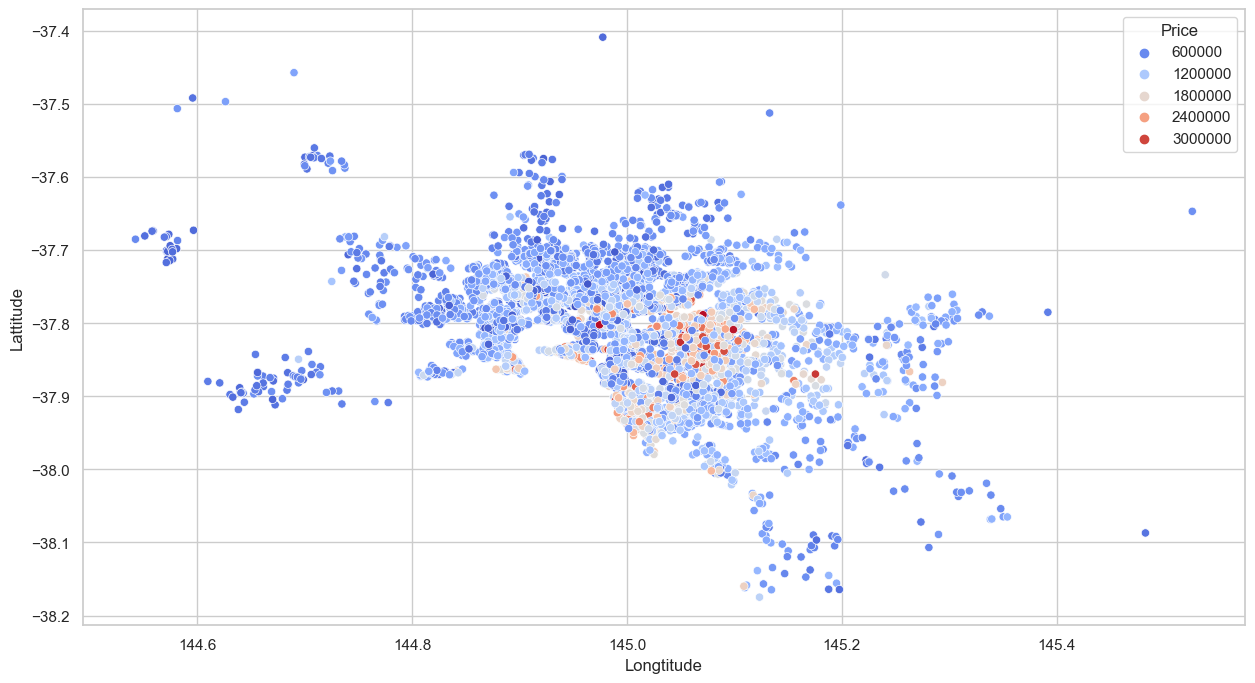

In [26]:
#Let's visualize the price by location. This data is from Melbourne, Australia, so we can plot the location of each house on a map of Melbourne and color the houses by price.
plt.figure(figsize=(15, 8))
sns.scatterplot(x="Longtitude", y="Lattitude", hue='Price', data=train_set, palette='coolwarm')

In [27]:
# We can see that the houses with the highest prices are located in the center of Melbourne, while the houses with the lowest prices are located in the suburbs.
# We can also see that the houses with the highest prices are located near the coast, while the houses with the lowest prices are located further away from the coast.
# As we can see from the correlation matrix displayed above, the 'distance' column is highly correlated with the 'Price' column. It refers to the distance to the center of Melbourne since from the correlation matrix we see that the greater the distance, the more house ('h') types and the less unit ('u') types.
#check nans in test_set

In [28]:
## the model
# KNeighborsRegressor
from sklearn import neighbors
n_neighbors = 2
model = neighbors.KNeighborsRegressor(n_neighbors)

features = ['Landsize', 'BuildingArea', 'YearBuilt', 'Distance', 'Lattitude', 'Longtitude', 'Car', 'Bedroom2', 'TotalRooms', 'DistanceCarsRatio', 'Suburb', 'Type_h', 'Type_t', 'Type_u', 'Regionname_Northern Metropolitan', 'Regionname_Northern Victoria', 'Regionname_South-Eastern Metropolitan', 'Regionname_Southern Metropolitan', 'Regionname_Western Metropolitan', 'Regionname_Western Victoria']
test_set = test_set[features]

x_train, y_train = train_set[features], train_set['Price']
# Let's scale the data before training the model
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
# We have to scale the test set as well
test_set = scaler.transform(test_set)

In [29]:
## fit the model
model.fit(x_train, y_train)

KNeighborsRegressor(n_neighbors=2)

----- EVALUATION ON TRAIN SET ------
RMSE 169959.31140873302
R^2:  0.9030414358459989


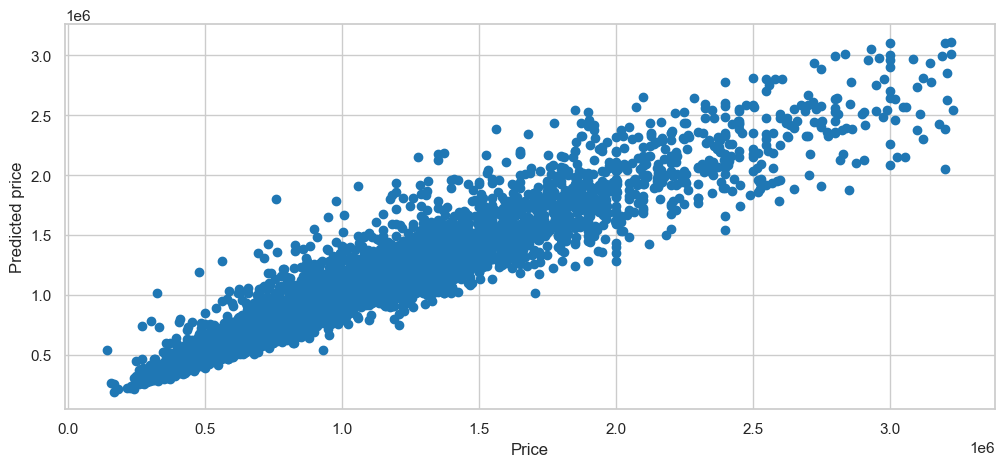

In [30]:
## predict training set
y_pred = model.predict(x_train)
## Evaluate the model and plot it
from sklearn.metrics import mean_squared_error, r2_score
print("----- EVALUATION ON TRAIN SET ------")
print("RMSE",np.sqrt(mean_squared_error(y_train, y_pred)))
print("R^2: ",r2_score(y_train, y_pred))
plt.scatter(y_train, y_pred)
plt.xlabel('Price')
plt.ylabel('Predicted price')
plt.show()

In [31]:
## predict the test set and generate the submission file
x_test = test_set
y_pred = model.predict(x_test)

df_output = pd.DataFrame(y_pred)
df_output = df_output.reset_index()
df_output.columns = ['index','Price']

df_output.to_csv('output/session1/submission.csv',index=False)

Explain the chosen model and why you think that is is the best

In [32]:
# We chose the KNeighborsRegressor model since a lot of our features, specially the categorical ones which we had to encode one way or another, are not linearly correlated with the 'Price' column, so we thought that a linear model would not be the best choice and indeed it was not (we tested both and the KNeighborsRegressor model performed significantly better). Furthermore, as we can see in the 'Price' histogram displayed above, the 'Price' column is skewed to the right, so we thought that a linear model would not be the best choice, since outliers would have a big impact on the model (KNN is generally less sensitive to outliers than linear regression).